In [ ]:
import pandas as pd

df = pd.read_csv("data/calories.csv")

print(df.shape)
df.head()

(15000, 9)


,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8,35.0


In [2]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   User_ID     15000 non-null  int64  
 1   Gender      15000 non-null  str    
 2   Age         15000 non-null  int64  
 3   Height      15000 non-null  float64
 4   Weight      15000 non-null  float64
 5   Duration    15000 non-null  float64
 6   Heart_Rate  15000 non-null  float64
 7   Body_Temp   15000 non-null  float64
 8   Calories    15000 non-null  float64
dtypes: float64(6), int64(2), str(1)
memory usage: 1.0 MB


,User_ID,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
count,1.500000e+04,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,1.497736e+07,42.789800,174.465133,74.966867,15.530600,95.518533,40.025453,89.539533
std,2.872851e+06,16.980264,14.258114,15.035657,8.319203,9.583328,0.779230,62.456978
min,1.000116e+07,20.000000,123.000000,36.000000,1.000000,67.000000,37.100000,1.000000
25%,1.247419e+07,28.000000,164.000000,63.000000,8.000000,88.000000,39.600000,35.000000
50%,1.499728e+07,39.000000,175.000000,74.000000,16.000000,96.000000,40.200000,79.000000
75%,1.744928e+07,56.000000,185.000000,87.000000,23.000000,103.000000,40.600000,138.000000
max,1.999965e+07,79.000000,222.000000,132.000000,30.000000,128.000000,41.500000,314.000000


In [3]:
# clean and explore data
print("Duplicates:", df.duplicated().sum())
print("Duplicate User_IDs:", df["User_ID"].duplicated().sum())

df = df.drop(columns=["User_ID"])
df.head()

Duplicates: 0
Duplicate User_IDs: 0


,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,female,27,154.0,58.0,10.0,81.0,39.8,35.0


Gender
female    7553
male      7447
Name: count, dtype: int64


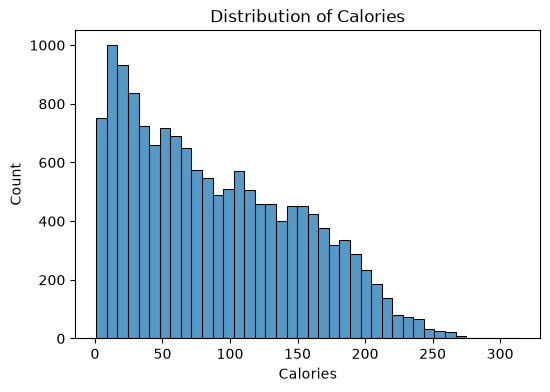

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

print(df["Gender"].value_counts())

plt.figure(figsize=(6, 4))
sns.histplot(df["Calories"], bins=40)
plt.title("Distribution of Calories")
plt.show()

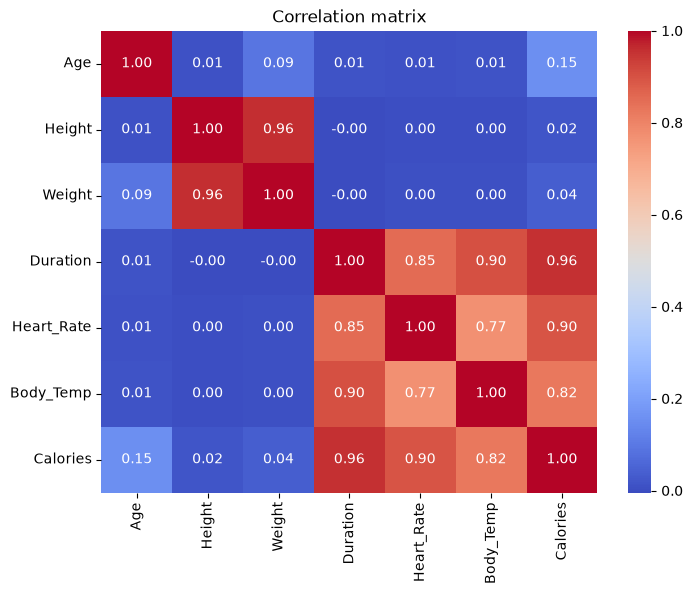

In [6]:
# correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation matrix")
plt.show()

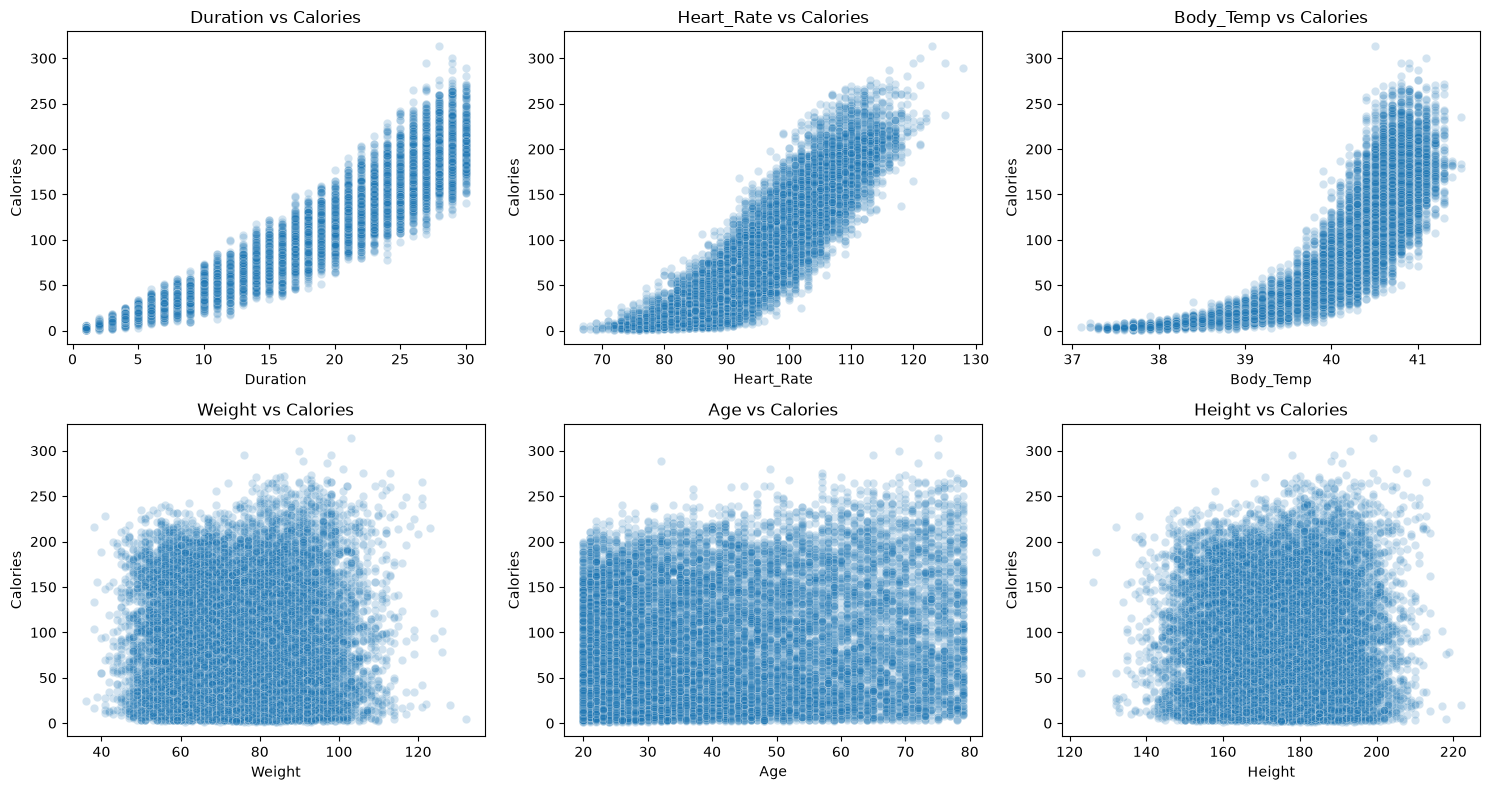

In [7]:
features = ["Duration", "Heart_Rate", "Body_Temp", "Weight", "Age", "Height"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, features):
    sns.scatterplot(data=df, x=col, y="Calories", alpha=0.2, ax=ax)
    ax.set_title(f"{col} vs Calories")
plt.tight_layout()
plt.show()

In [8]:
# split the data into 80% for training the model and 20% for testing
from sklearn.model_selection import train_test_split

X = df.drop(columns=["Calories"])
y = df["Calories"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape)


(12000, 7) (3000, 7)


In [10]:
# build a reusable pipeline function
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression

def build_pipeline(numeric_cols, categorical_cols, model=None):
    preprocessor = ColumnTransformer([
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(drop="first"), categorical_cols),
    ])
    return Pipeline([
        ("prep", preprocessor),
        ("model", model or LinearRegression()),
    ])

In [15]:
# train and evaluate both models
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate(pipe,X_train,X_test,y_trian,y_test):
    pipe.fit(X_train,y_train)
    pred = pipe.predict(X_test)
    return {
        "MAE" : mean_absolute_error(y_test,pred),
        "RMSE" : np.sqrt(mean_squared_error(y_test,pred)),
        "R2" : r2_score(y_test,pred),
    }
cat_cols = ["Gender"]
# Model A: with Body_Temp
num_A = ["Age", "Height", "Weight", "Duration", "Heart_Rate", "Body_Temp"]
pipe_A = build_pipeline(num_A,cat_cols)
print("Model A (with Body_Temp):", evaluate(pipe_A, X_train, X_test, y_train, y_test))


# Actual model without body_temp
# Model B: with Body_Temp
num_B = ["Age", "Height", "Weight", "Duration", "Heart_Rate"]
pipe_B = build_pipeline(num_B,cat_cols)
print("Model B (without Body_Temp):", evaluate(pipe_B, X_train, X_test, y_train, y_test))


Model A (with Body_Temp): {'MAE': 8.44151355384971, 'RMSE': np.float64(11.488940149152876), 'R2': 0.9672937151257295}
Model B (without Body_Temp): {'MAE': 9.687280684240442, 'RMSE': np.float64(12.866980465285634), 'R2': 0.9589772694590663}


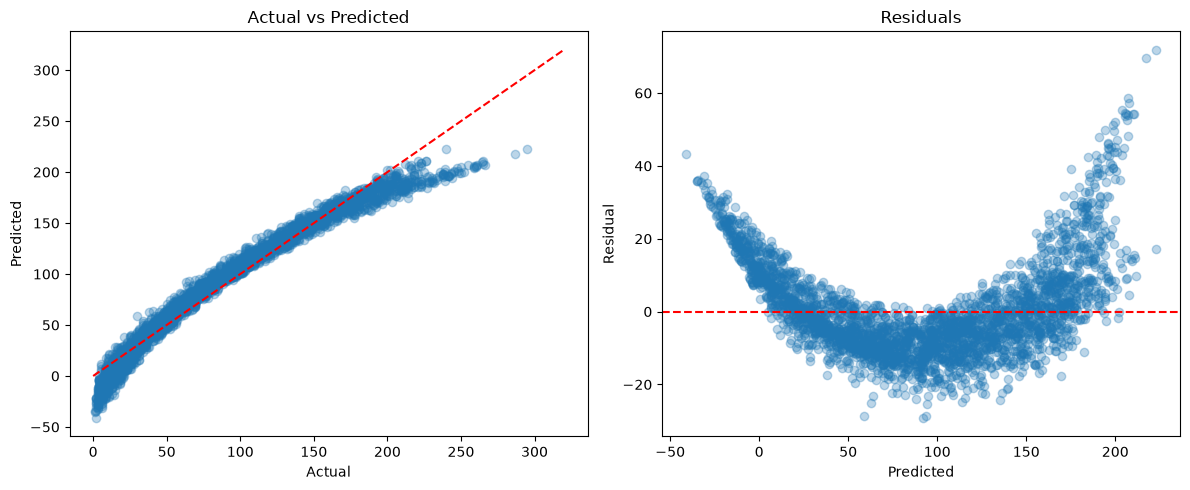

In [18]:
# plot actual vs. predicted and residulas (Model B)
pred_B = pipe_B.predict(X_test)
residuals = y_test - pred_B

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(y_test, pred_B, alpha=0.3)
axes[0].plot([0, 320], [0, 320], "r--")
axes[0].set_xlabel("Actual")
axes[0].set_ylabel("Predicted")
axes[0].set_title("Actual vs Predicted")

axes[1].scatter(pred_B, residuals, alpha=0.3)
axes[1].axhline(0, color="r", linestyle="--")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Residual")
axes[1].set_title("Residuals")

plt.tight_layout()
plt.show()


In [20]:
#add polynomial features
#The U-shaped residual plot is the key finding. It means the relationship between the inputs and calories is curved, and a straight-line model can't follow it. The model overpredicts in the middle and underpredicts at the extremes (or the reverse). The fix is to give the model curved terms to work with.
#Scaling comes before the polynomial step on purpose. Squaring unscaled values like heart rate (around 100) creates huge numbers, which can cause numerical problems.

from sklearn.preprocessing import PolynomialFeatures

def build_poly_pipeline(numeric_cols, categorical_cols, degree=2, model=None):
    preprocessor = ColumnTransformer([
        ("num", Pipeline([
            ("scale", StandardScaler()),
            ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
        ]), numeric_cols),
        ("cat", OneHotEncoder(drop="first"), categorical_cols),
    ])
    return Pipeline([
        ("prep", preprocessor),
        ("model", model or LinearRegression()),
    ])

pipe_poly2 = build_poly_pipeline(num_B, cat_cols, degree=2)
print("Poly degree 2:", evaluate(pipe_poly2, X_train, X_test, y_train, y_test))

pipe_poly3 = build_poly_pipeline(num_B, cat_cols, degree=3)
print("Poly degree 3:", evaluate(pipe_poly3, X_train, X_test, y_train, y_test))

Poly degree 2: {'MAE': 3.1471702759284823, 'RMSE': np.float64(4.526755954123583), 'R2': 0.994922552469997}
Poly degree 3: {'MAE': 2.262025094807008, 'RMSE': np.float64(3.6750658082366865), 'R2': 0.9966534176082371}


In [25]:
# compare with cross-validation
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import Ridge

candidates = {
    "Linear": build_pipeline(num_B, cat_cols),
    "Poly deg 2": build_poly_pipeline(num_B, cat_cols, degree=2),
    "Poly deg 3": build_poly_pipeline(num_B, cat_cols, degree=3),
    "Poly deg 2 + Ridge": build_poly_pipeline(num_B, cat_cols, degree=2, model=Ridge(alpha=1.0)),
    "Poly deg 3 + Ridge": build_poly_pipeline(num_B, cat_cols, degree=3, model=Ridge(alpha=10.0)),
}

for name, pipe in candidates.items():
    scores = cross_val_score(pipe, X_train, y_train, cv=5,
                             scoring="neg_mean_absolute_error")
    print(f"{name:22s} CV MAE: {-scores.mean():.2f} (+/- {scores.std():.2f})")
    

Linear                 CV MAE: 9.55 (+/- 0.17)
Poly deg 2             CV MAE: 3.14 (+/- 0.04)
Poly deg 3             CV MAE: 2.27 (+/- 0.02)
Poly deg 2 + Ridge     CV MAE: 3.14 (+/- 0.04)
Poly deg 3 + Ridge     CV MAE: 2.28 (+/- 0.03)


In [26]:
# poly deg 3 is the best model out of them with small added complexity in comparison with deg 2
final = build_poly_pipeline(num_B, cat_cols, degree=3)
print("Final test metrics:", evaluate(final, X_train, X_test, y_train, y_test))

Final test metrics: {'MAE': 2.262025094807008, 'RMSE': np.float64(3.6750658082366865), 'R2': 0.9966534176082371}
